In [1]:
import numpy as np
import os
from utils.transformation_sixd import smplx_to_6d, sixd_to_smplx
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# openpose stats

root="final_dataset"
i=0

for gait in os.listdir(root):
    gait_path=os.path.join(root,gait)
    lengths=[]
    x_coords=[]
    y_coords=[]
    z_coords=[]
    for take in os.listdir(gait_path):
        sequence_path=os.path.join(gait_path,take,"split_subjects/0/keypoints_3d/smpl-keypoints-3d_cut.npy")
        data=np.load(sequence_path)
        #print(data[0,0,:3])
        x_coords.append(np.max(data[:,i,0]))
        x_coords.append(np.min(data[:,i,0]))
        y_coords.append(np.max(data[:,i,1]))
        y_coords.append(np.min(data[:,i,1]))
        z_coords.append(np.max(data[:,i,2]))
        z_coords.append(np.min(data[:,i,2]))
        lengths.append(data.shape[0])
    #print(gait,lengths)
    #print(gait,max(lengths),min(lengths))
    print(gait,max(x_coords), max(y_coords), max(z_coords))
    print(gait,min(x_coords), min(y_coords), min(z_coords))



gait_011 0.6284517597699179 2.0029172129390833 1.3952250170717944
gait_011 -0.7750142675976146 0.8451797277411195 -1.3823186344485985
gait_052 0.6873598366739131 1.3811971815038944 1.3715027981082446
gait_052 -0.5689291981268328 0.6905244357660919 -1.587894619501878
gait_114 0.636942911332416 1.587396929456631 1.4208496727254647
gait_114 -0.6845426368929389 0.8322612488219651 -1.3041865405596862
gait_133 0.6797287888115038 1.3580241516581066 1.2743402502498604
gait_133 -0.5748530266666068 0.6685180810125675 -1.245905123307373
gait_354 0.5698294881242808 1.259312432417369 1.2410462018255697
gait_354 -0.6656624869267568 0.8087225268052021 -1.3147315305198293
gait_390 0.6537345367513068 1.770363017621138 1.5007060372875203
gait_390 -0.7331151220609871 0.9015451367698802 -1.5480681034754027
gait_520 0.8136788771561108 1.9756957064961131 1.441245313114038
gait_520 -0.9340374284130158 0.9158549456943204 -1.3589324282998692
gait_682 0.7335839279710116 1.643421970459998 1.2935543483366663
gait

In [3]:
# 6d stats

root="final_dataset"
i=0

for gait in os.listdir(root):
    gait_path=os.path.join(root,gait)
    lengths=[]
    x_coords=[]
    y_coords=[]
    z_coords=[]
    motion_shapes_max=[]
    motion_shapes_min=[]
    for take in os.listdir(gait_path):
        sequence_path=os.path.join(gait_path,take,"split_subjects/0/fit-smplx/smplx-params_cut.npz")
        data=smplx_to_6d(sequence_path)
        transl=data['transl']
        x_coords.append(np.max(transl[:,0]))
        x_coords.append(np.min(transl[:,0]))
        y_coords.append(np.max(transl[:,1]))
        y_coords.append(np.min(transl[:,1]))
        z_coords.append(np.max(transl[:,2]))
        z_coords.append(np.min(transl[:,2]))
        motion=data['motion_6d']
        motion_shapes_max.append(np.max(motion))
        motion_shapes_min.append(np.min(motion))
    print(gait,max(x_coords), max(y_coords), max(z_coords))
    print(gait,min(x_coords), min(y_coords), min(z_coords))
    print(gait,max(motion_shapes_max), min(motion_shapes_min))
    print("==============")


gait_011 0.09374523 0.055384636 0.0
gait_011 -1.1350725 -0.42987418 -2.4117427
gait_011 1.0 -0.99997354
gait_052 0.12798023 0.051422477 0.053468466
gait_052 -1.1897724 -0.08875799 -2.8032281
gait_052 1.0 -0.9999949
gait_114 0.24569687 0.043065548 0.18704426
gait_114 -1.1354383 -0.11314201 -2.34733
gait_114 1.0 -0.99997026
gait_133 0.16646948 0.053118944 0.06509054
gait_133 -1.0673912 -0.19284558 -2.338767
gait_133 1.0 -0.99997073
gait_354 0.0 0.043230534 0.120954275
gait_354 -1.0868188 -0.10143417 -2.2336473
gait_354 1.0 -0.9999715
gait_390 0.11260483 0.035903215 0.15477026
gait_390 -1.1755431 -0.20374644 -2.7939591
gait_390 1.0 -0.9991249
gait_520 0.17789656 0.07000399 0.34440237
gait_520 -1.4209433 -0.25395608 -2.4057722
gait_520 1.0 -0.9994906
gait_682 0.2860626 0.09554529 0.04395318
gait_682 -1.0873425 -0.15967059 -2.4242754
gait_682 1.0 -0.99999255
gait_700 0.118005544 0.048950195 0.12302661
gait_700 -0.954044 -0.39224267 -2.408161
gait_700 1.0 -0.9999713
gait_740 0.022275984 0.04

gait_011 [63, 67, 44, 45, 88, 83, 114, 64, 62, 111, 121, 72, 77, 50, 45, 88, 86, 112, 69, 65, 115, 121]
gait_011 121 44
gait_052 [99, 91, 83, 60, 70, 99, 107, 71, 75, 124, 123, 64, 69, 71, 52, 51, 116, 125, 71, 75, 143, 133]
gait_052 143 51
gait_114 [79, 69, 57, 48, 129, 154, 146, 69, 60, 182, 145, 70, 58, 53, 48, 144, 155, 146, 69, 51, 122, 110]
gait_114 182 48
gait_133 [58, 44, 41, 46, 94, 122, 112, 58, 47, 129, 127, 70, 52, 46, 61, 167, 126, 102, 54, 51, 124, 149]
gait_133 167 41
gait_354 [76, 79, 57, 50, 120, 139, 116, 52, 62, 193, 181, 81, 62, 47, 54, 172, 116, 155, 63, 62, 186, 181]
gait_354 193 47
gait_390 [96, 96, 69, 69, 118, 147, 109, 92, 93, 238, 177, 96, 88, 69, 69, 148, 132, 119, 92, 93, 188, 177]
gait_390 238 69
gait_520 [82, 80, 64, 55, 132, 169, 153, 94, 73, 199, 157, 106, 80, 69, 65, 178, 166, 122, 84, 73, 174, 169]
gait_520 199 55
gait_682 [168, 80, 73, 66, 106, 112, 123, 107, 73, 159, 120, 62, 83, 51, 50, 106, 122, 103, 69, 73, 144, 190]
gait_682 190 50
gait_700 [71,

C:\Users\Rui\AppData\Local\Temp\ipykernel_50828\1770723058.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Subject', y='Sequence Length', data=df, palette='Set3')


          count        mean        std   min    25%    50%     75%    max
Subject                                                                  
gait_011   22.0   80.090909  25.823410  44.0  63.25   74.5  105.25  121.0
gait_052   22.0   89.636364  27.789250  51.0  70.25   79.0  113.75  143.0
gait_114   22.0   98.363636  44.550181  48.0  58.50   74.5  144.75  182.0
gait_133   22.0   85.454545  40.091238  41.0  51.25   65.5  123.50  167.0
gait_354   22.0  104.727273  52.542211  47.0  62.00   80.0  151.00  193.0
gait_390   22.0  117.045455  45.155264  69.0  92.00   96.0  143.25  238.0
gait_520   22.0  115.636364  46.722632  55.0  74.75  100.0  163.75  199.0
gait_682   22.0  101.818182  38.478982  50.0  73.00  104.5  121.50  190.0
gait_700   22.0  116.454545  57.178690  50.0  70.25   77.0  173.25  213.0
gait_740   22.0   93.909091  38.325559  58.0  67.00   78.5  111.00  202.0
gait_753   22.0   97.045455  57.342312  32.0  46.00  100.0  121.75  232.0
gait_766   22.0  101.545455  49.409588

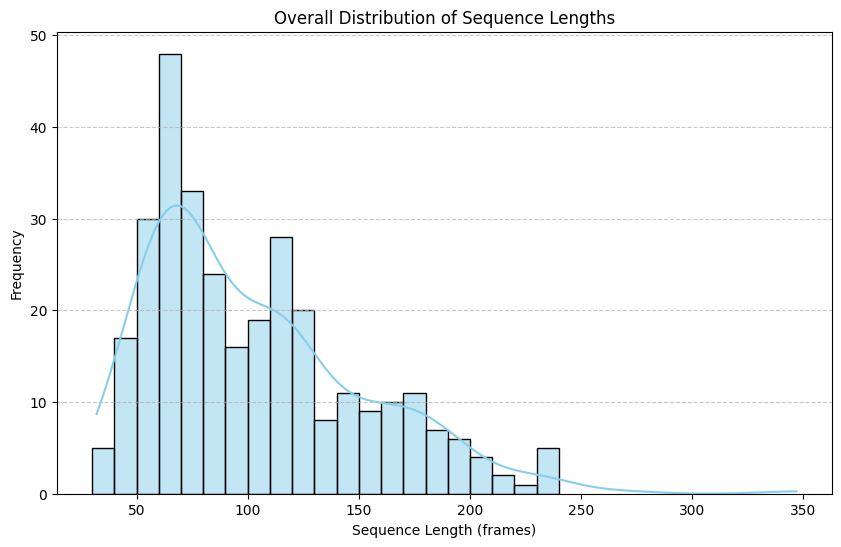

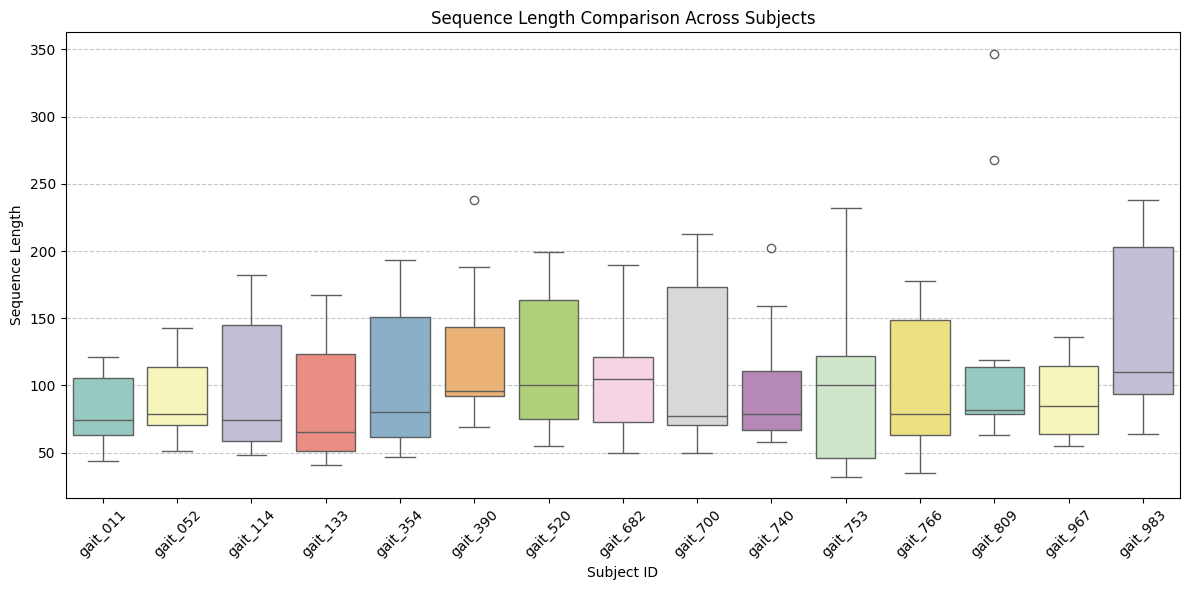

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np
#sequence length stats
data_dict={}
root="final_dataset"
for gait in os.listdir(root):
    gait_path=os.path.join(root,gait)
    lengths=[]
    for take in os.listdir(gait_path):
        #print(take)
        sequence_path=os.path.join(gait_path,take,"split_subjects/0/keypoints_3d/smpl-keypoints-3d_cut.npy")
        data=np.load(sequence_path)
        lengths.append(data.shape[0])
    data_dict[gait]=lengths
    print(gait,lengths)
    print(gait,max(lengths),min(lengths))


# 2. Flatten data for the histogram
all_lengths = [length for lengths in data_dict.values() for length in lengths]

# 3. Create a DataFrame for subject-wise comparison (Boxplot)
df_list = []
for subject, lengths in data_dict.items():
    for length in lengths:
        df_list.append({'Subject': subject, 'Sequence Length': length})
df = pd.DataFrame(df_list)

# --- PLOT 1: Overall Histogram ---
plt.figure(figsize=(10, 6))
sns.histplot(all_lengths, 
             kde=True, 
             binwidth=10, 
             binrange=(30, 240), 
             color='skyblue')
plt.title('Overall Distribution of Sequence Lengths')
plt.xlabel('Sequence Length (frames)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('overall_distribution.png')
# plt.show() # Uncomment to view locally

# --- PLOT 2: Subject-wise Boxplot ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='Subject', y='Sequence Length', data=df, palette='Set3')
plt.title('Sequence Length Comparison Across Subjects')
plt.xlabel('Subject ID')
plt.ylabel('Sequence Length')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('subject_comparison.png')
# plt.show() # Uncomment to view locally

# 4. Print quick summary stats
print(df.groupby('Subject')['Sequence Length'].describe())

In [7]:
df['Sequence Length'].sum()

32702

In [9]:
df['Sequence Length'].mean()

103.4873417721519

In [18]:
data_dict = {}
root = "final_dataset"
for gait in os.listdir(root):
    gait_path = os.path.join(root, gait)
    lengths = []
    for take in os.listdir(gait_path):
        action = take.split("_")[2]
        sequence_path = os.path.join(gait_path, take, "split_subjects/0/keypoints_3d/smpl-keypoints-3d_cut.npy")
        data = np.load(sequence_path)
        lengths.append((data.shape[0], action))
    data_dict[gait] = lengths

# Flatten data for the histogram
all_lengths = [length for length, action in (item for lengths in data_dict.values() for item in lengths)]

# Create a DataFrame with Subject, Action, and Sequence Length
df_list = []
for subject, lengths in data_dict.items():
    for length, action in lengths:
        df_list.append({'Subject': subject, 'Action': action, 'Sequence Length': length})
df = pd.DataFrame(df_list)

# Average frame count per action
avg_per_action = df.groupby('Action')['Sequence Length'].mean()
print(avg_per_action)

Action
a1     76.310345
a2     57.250000
a3    133.536585
a4     74.327586
a5    165.172414
Name: Sequence Length, dtype: float64


In [19]:
df.groupby('Action')['Sequence Length'].std()

Action
a1    19.286580
a2    12.635201
a3    33.229912
a4    17.553315
a5    45.193594
Name: Sequence Length, dtype: float64

In [2]:
import numpy as np
def subtract_root(data):
    #only after frames have been cut
    #also deletes 0 row
    if data.shape[1]==25:
        data=data[:,:, :3]
        root = (data[:,8,:]+data[:, 9, :])/2
        data=np.delete((data - root[:,np.newaxis, :]), (1,8), axis=1)
        assert data.shape[1]==23
    elif data.shape[1]==135:
        root = data[:,:3]
        data[:,:3]= data[:,:3] - root
    else:
        raise ValueError(f"Unknown keypoint type")

    return data

def extract_trajectory(data):
    # Extract the trajectory of the root joint (assuming it's the first joint)
    if data.shape[1]==25:
        data=data[:,:, :3]
        root = (data[:,8,:]+data[:, 9, :])/2
    trajectory = root[:,np.newaxis, :]  # Shape: (num_frames, 3)
    trajectory=trajectory-trajectory[0:1,:,:]  # Normalize to start at origin
    return trajectory

def root_normalize_and_trajectory(data):
    assert len(data.shape)==3  # (frames, joints, 3)
    if data.shape[1]==23:
        root = (data[:,7]+data[:, 10])/2
        data=(data - root[:,np.newaxis, :])
        return data.reshape(data.shape[0], -1)
    elif data.shape[1]==22:
        root=data[:,0,:].copy()
        data=(data - root[:,np.newaxis, :]) 
        return data.reshape(data.shape[0], -1)
    else:
        raise ValueError(f"Unknown keypoint type")



In [3]:
#this cell

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from tslearn.metrics  import dtw_path_from_metric
from utils.transformation_sixd import smplx_to_6d
from utils.metrics import pose_distance_metric, mpjpe_distance_metric, pampjpe_distance_metric, calculate_jitter
# Initialize list OUTSIDE the loop to collect all subjects
all_results = []
root = "final_dataset"

for gait in os.listdir(root):
    gait_path = os.path.join(root, gait)
    if not os.path.isdir(gait_path): continue
    
    print(f"Processing gait: {gait}...")
    
    for take in os.listdir(gait_path):
        # We look for c1 and match it with its c2 pair
        if '_c1' in take:

            # 1. Load 3D Keypoints
            path_orth = os.path.join(gait_path, take, "split_subjects/0/keypoints_3d/smpl-keypoints-3d_cut.npy")
            path_crouch = os.path.join(gait_path, take.replace('c1','c2'), "split_subjects/0/keypoints_3d/smpl-keypoints-3d_cut.npy")
            
            data_3d_1 = np.load(path_orth)
            data_3d_2 = np.load(path_crouch)
            x=data_3d_1[:,:,:3]
            y=data_3d_2[:,:,:3]
            #pure coordinates
            data_3d_1_raw = x.reshape(x.shape[0], -1)
            data_3d_2_raw = y.reshape(y.shape[0], -1)
            path_3d, dist_3d_raw = dtw_path_from_metric(data_3d_1_raw, data_3d_2_raw, metric=mpjpe_distance_metric)
            mpjpe_raw = dist_3d_raw / len(path_3d)

            #jitter
            jitter_c1 = calculate_jitter(x)
            jitter_c2 = calculate_jitter(y)


            data_3d_1_traj = extract_trajectory(data_3d_1)
            data_3d_2_traj = extract_trajectory(data_3d_2)
            data_3d_1_traj = data_3d_1_traj.reshape(data_3d_1_traj.shape[0], -1)
            data_3d_2_traj = data_3d_2_traj.reshape(data_3d_2_traj.shape[0], -1)
            path_3d_traj, dist_3d_traj = dtw_path_from_metric(data_3d_1_traj, data_3d_2_traj)
            norm_dist_3d_traj = dist_3d_traj / len(path_3d_traj)
            data_3d_1 = np.delete((data_3d_1), (1,8), axis=1)
            data_3d_2 = np.delete((data_3d_2), (1,8), axis=1)
            data_3d_1 = data_3d_1[:,:,:3]
            data_3d_2 = data_3d_2[:,:,:3]
            pam1=root_normalize_and_trajectory(data_3d_1)
            pam2=root_normalize_and_trajectory(data_3d_2)
            
            # 2. Load 6D Parameters
            path_orth_6d = os.path.join(gait_path, take, "split_subjects/0/fit-smplx/smplx-params_cut.npz")
            path_crouch_6d = os.path.join(gait_path, take.replace('c1','c2'), "split_subjects/0/fit-smplx/smplx-params_cut.npz")

            path_orth_6d_keypoints = os.path.join(gait_path, take, "split_subjects/0/fit-smplx/smpl-keypoints-3d_cut.npy")
            path_crouch_6d_keypoints = os.path.join(gait_path, take.replace('c1','c2'), "split_subjects/0/fit-smplx/smpl-keypoints-3d_cut.npy")

            data_6d_keypoints = np.load(path_orth_6d_keypoints)
            data_6d_keypoints_2 = np.load(path_crouch_6d_keypoints)
            pam1_6d = root_normalize_and_trajectory(data_6d_keypoints)
            pam2_6d = root_normalize_and_trajectory(data_6d_keypoints_2)

            data_6d_1 = smplx_to_6d(path_orth_6d)
            data_6d_2 = smplx_to_6d(path_crouch_6d)

            # 3. Calculate DTW with Normalization (distance / path_length)
            data_6d_keypoints = data_6d_keypoints.reshape(data_6d_keypoints.shape[0], -1)
            data_6d_keypoints_2 = data_6d_keypoints_2.reshape(data_6d_keypoints_2.shape[0], -1)
            path_6d_keypoints, mpjpe_6d = dtw_path_from_metric(data_6d_keypoints, data_6d_keypoints_2, metric=mpjpe_distance_metric)
            mpjpe_6d = mpjpe_6d / len(path_6d_keypoints)
            data_3d_1 = data_3d_1.reshape(data_3d_1.shape[0], -1)
            data_3d_2 = data_3d_2.reshape(data_3d_2.shape[0], -1)
            path_3d, dist_3d = dtw_path_from_metric(data_3d_1, data_3d_2, metric=mpjpe_distance_metric)
            mpjpe_3d = dist_3d / len(path_3d)


            #pampjpe 
            path_3d, dist_3d = dtw_path_from_metric(pam1, pam2, metric=pampjpe_distance_metric)
            pampjpe_3d = dist_3d / len(path_3d)
            path_6d, dist_6d = dtw_path_from_metric(pam1_6d, pam2_6d, metric=pampjpe_distance_metric)
            pampjpe_6d = dist_6d / len(path_6d)


            path_6d_pose, dist_6d_pose = dtw_path_from_metric(data_6d_1['motion_6d'], data_6d_2['motion_6d'], metric=pose_distance_metric)
            mpjre = dist_6d_pose / len(path_6d_pose)

            path_6d_transl, dist_6d_transl = dtw_path_from_metric(data_6d_1['transl'], data_6d_2['transl'])
            norm_dist_6d_transl = dist_6d_transl / len(path_6d_transl)

            # 4. Append to global list
            all_results.append({
                'subject_gait': gait, # This identifies your 11 subjects
                'take_id': take,
                'mpjpe_3d': mpjpe_3d,
                'mpjpe_raw': mpjpe_raw,
                'dtw_3d_traj': norm_dist_3d_traj,
                'mpjre': mpjre,
                'dtw_6d_transl': norm_dist_6d_transl,
                'mpjpe_6d': mpjpe_6d,
                'jitter_c1': jitter_c1,
                'jitter_c2': jitter_c2,
                'pampjpe_3d': pampjpe_3d,
                'pampjpe_6d': pampjpe_6d

            })

# Create DataFrame
df = pd.DataFrame(all_results)

Processing gait: gait_011...
Processing gait: gait_052...
Processing gait: gait_114...
Processing gait: gait_133...
Processing gait: gait_354...
Processing gait: gait_390...
Processing gait: gait_520...
Processing gait: gait_682...
Processing gait: gait_700...
Processing gait: gait_740...
Processing gait: gait_753...
Processing gait: gait_766...
Processing gait: gait_809...
Processing gait: gait_967...
Processing gait: gait_983...


In [3]:
df = pd.read_csv("comparison_results.csv")
df

,subject_gait,take_id,mpjpe_3d,mpjpe_raw,dtw_3d_traj,mpjre,dtw_6d_transl,mpjpe_6d,jitter_c1,jitter_c2,pampjpe_3d,pampjpe_6d,action
0,gait_011,20251107_c1_a1_Take1,0.097548,0.092370,0.048422,0.103877,0.038962,0.076323,606.531860,470.055145,0.031675,0.023463,a1
1,gait_011,20251107_c1_a1_Take2,0.168633,0.159117,0.096565,0.108897,0.108291,0.133566,614.468811,384.464996,0.042759,0.032270,a1
2,gait_011,20251107_c1_a2_Take1,0.265867,0.248688,0.055022,0.144425,0.055232,0.195136,712.170227,535.716309,0.076264,0.054312,a2
3,gait_011,20251107_c1_a2_Take2,0.389645,0.367759,0.115128,0.167489,0.111348,0.324365,662.944702,516.972107,0.096844,0.072115,a2
4,gait_011,20251107_c1_a3_Take1,0.230355,0.217321,0.125688,0.184247,0.123724,0.191244,509.567535,376.815186,0.077449,0.057188,a3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,gait_983,20251222_c1_a3_Take3,0.132554,0.126223,0.108580,0.113542,0.111581,0.118302,384.907867,254.058838,0.033949,0.026379,a3
154,gait_983,20251222_c1_a4_Take1,0.126177,0.119271,0.089348,0.221096,0.090999,0.102144,410.870575,327.944183,0.029883,0.026173,a4
155,gait_983,20251222_c1_a4_Take2,0.145771,0.137111,0.062529,0.206529,0.063492,0.115301,477.799866,327.763611,0.037665,0.030284,a4
156,gait_983,20251222_c1_a5_Take1,0.119450,0.113423,0.072125,0.165864,0.070507,0.107793,369.308929,245.430618,0.047532,0.040063,a5


In [ ]:
df.to_csv("comparison_results.csv", index=False)

In [4]:
# List of columns to exclude
exclude_cols = ['subject_gait', 'take_id', 'pampjpe_6d', 'mpjpe_raw', 'action', 'mpjpe_6d']  # Add any other columns you want to exclude

# Select all columns except the excluded ones and calculate mean and std
# This assumes your dataframe is named 'df'
stats = df.drop(columns=exclude_cols).agg(['mean', 'std'])

# To view the results
stats


,mpjpe_3d,dtw_3d_traj,mpjre,dtw_6d_transl,jitter_c1,jitter_c2,pampjpe_3d
mean,0.155847,0.079487,0.164279,0.081027,382.891599,347.412508,0.048852
std,0.057886,0.051404,0.059047,0.048598,89.064859,69.773357,0.019303


In [5]:
stats['jitter']=(stats['jitter_c1']+stats['jitter_c2'])/2

In [ ]:
stats.drop(columns=['jitter_c1', 'jitter_c2'], inplace=True)

,mpjpe_3d,dtw_3d_traj,mpjre,dtw_6d_transl,jitter_c1,jitter_c2,pampjpe_3d,jitter
mean,0.155847,0.079487,0.164279,0.081027,382.891599,347.412508,0.048852,365.152053
std,0.057886,0.051404,0.059047,0.048598,89.064859,69.773357,0.019303,79.419108


In [24]:
df.keys()

Index(['subject_gait', 'take_id', 'mpjpe_3d', 'mpjpe_raw', 'dtw_3d_traj',
       'mpjre', 'dtw_6d_transl', 'mpjpe_6d', 'jitter_c1', 'jitter_c2',
       'pampjpe_3d', 'pampjpe_6d', 'action'],
      dtype='object')

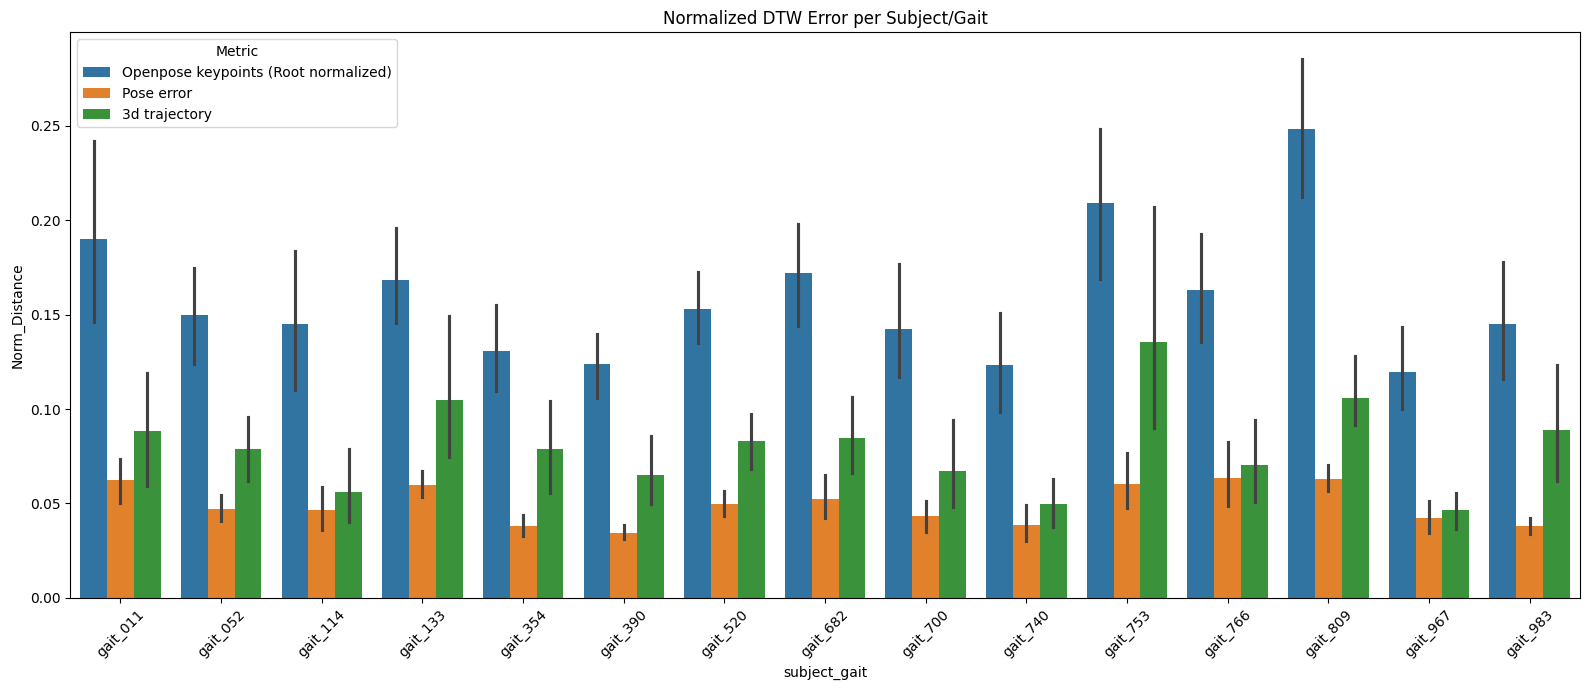

In [11]:
# --- Visualization ---
plt.figure(figsize=(16, 7))

# 1. Melt the dataframe as you did
df_melted = df.melt(id_vars='subject_gait', 
                    value_vars=['mpjpe_3d', 'pampjpe_3d', 'dtw_3d_traj'], 
                    var_name='Metric', value_name='Norm_Distance')

# 2. Map the technical names to descriptive names
metric_names = {
    'mpjpe_3d': 'Openpose keypoints (Root normalized)',
    'mpjre': 'Openpose keypoints (raw)',
    'jitter_c1': 'Jitter c1',
    'jitter_c2': 'Jitter c2',
    'dtw_3d_traj': '3d trajectory',
    'pampjpe_3d': 'Pose error',
    'pampjpe_6d': 'Translation error'
}
df_melted['Metric'] = df_melted['Metric'].map(metric_names)

# 3. Plot (The legend will now use the new names)
sns.barplot(data=df_melted, x='subject_gait', y='Norm_Distance', hue='Metric')

plt.xticks(rotation=45)
plt.title('Normalized DTW Error per Subject/Gait')
plt.tight_layout()
plt.savefig('dtw_analysis_3d.png')
plt.show()

In [28]:
# 1. Extract the action from 'take_id'
# split('_') creates a list: ['20251107', 'c1', 'a1', 'Take1']
# .str[2] grabs the third element ('a1')
df['action'] = df['take_id'].str.split('_').str[2]

# 2. Group by the new 'action' column and calculate the mean
result = df.groupby('action')[['mpjpe_3d', 'pampjpe_3d', 'mpjre']].mean().reset_index()

print(result)

  action  mpjpe_3d  pampjpe_3d     mpjre
0     a1  0.159492    0.047993  0.148552
1     a2  0.152472    0.048327  0.151546
2     a3  0.166854    0.051306  0.158932
3     a4  0.137880    0.042215  0.182038
4     a5  0.158097    0.053420  0.182979


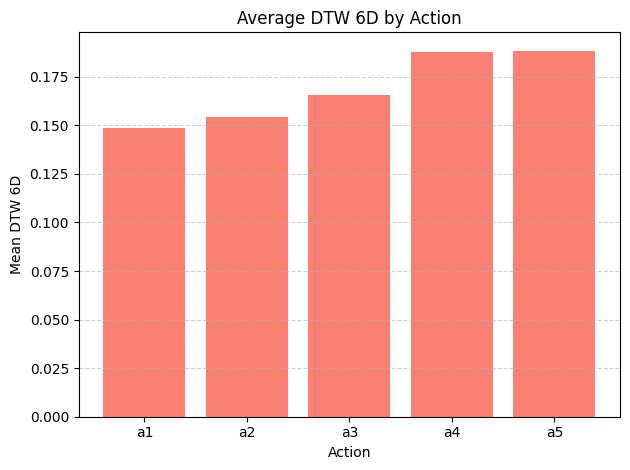

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare data
df['action'] = df['take_id'].str.split('_').str[2]
avg_df = df.groupby('action')[['dtw_3d', 'dtw_6d_pose']].mean().sort_index()

# 2. Plot DTW 3D
plt.bar(avg_df.index, avg_df['dtw_3d'], color='skyblue')
plt.title('Average DTW 3D by Action')
plt.xlabel('Action')
plt.ylabel('Mean DTW 3D')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('dtw_3d_bar.png')

plt.clf() # Clear plot for the next one

# 3. Plot DTW 6D
plt.bar(avg_df.index, avg_df['dtw_6d_pose'], color='salmon')
plt.title('Average DTW 6D by Action')
plt.xlabel('Action')
plt.ylabel('Mean DTW 6D')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('dtw_6d_pose_bar.png')

In [ ]:
print(all_resultsresults)

[{'gait': 'gait_766', 'dtw_3d': 257.22729875865355, 'dtw_6d': 556.3910890236066}, {'gait': 'gait_766', 'dtw_3d': 262.0715347137274, 'dtw_6d': 550.8895909321909}, {'gait': 'gait_766', 'dtw_3d': 156.56831556311957, 'dtw_6d': 311.36184463258724}, {'gait': 'gait_766', 'dtw_3d': 147.89771738866287, 'dtw_6d': 324.51053197266083}, {'gait': 'gait_766', 'dtw_3d': 376.5585609336431, 'dtw_6d': 877.787851217472}, {'gait': 'gait_766', 'dtw_3d': 653.8445590075665, 'dtw_6d': 1055.9547319128442}, {'gait': 'gait_766', 'dtw_3d': 652.6155238174306, 'dtw_6d': 2467.754750863309}, {'gait': 'gait_766', 'dtw_3d': 106.33508629687083, 'dtw_6d': 411.24346943436376}, {'gait': 'gait_766', 'dtw_3d': 236.22605448792285, 'dtw_6d': 651.2689270076544}, {'gait': 'gait_766', 'dtw_3d': 324.1757838339478, 'dtw_6d': 1001.6466661253216}, {'gait': 'gait_766', 'dtw_3d': 351.42890077630506, 'dtw_6d': 956.3273971356257}]


In [13]:
np.load("results/sixd_baseline/config_sdtw3/model000026013/dtw_metrics.npy", allow_pickle=True)

array([{'sample_id': 0, 'dtw_distance_geodesic': 0.05136032828126359, 'dtw_distance': 0.46584171878320796, 'reference_frames': 132, 'generated_frames': 240},
       {'sample_id': 1, 'dtw_distance_geodesic': 0.08877869177599058, 'dtw_distance': 0.43229053881174573, 'reference_frames': 165, 'generated_frames': 240},
       {'sample_id': 2, 'dtw_distance_geodesic': 0.05830280788917692, 'dtw_distance': 0.5125634659004087, 'reference_frames': 59, 'generated_frames': 240},
       {'sample_id': 3, 'dtw_distance_geodesic': 0.04192969152857623, 'dtw_distance': 0.2078400416605508, 'reference_frames': 232, 'generated_frames': 240},
       {'sample_id': 4, 'dtw_distance_geodesic': 0.23901437037329665, 'dtw_distance': 0.5118362046927214, 'reference_frames': 82, 'generated_frames': 240},
       {'sample_id': 5, 'dtw_distance_geodesic': 0.18107058991683533, 'dtw_distance': 0.5441719396427894, 'reference_frames': 69, 'generated_frames': 240},
       {'sample_id': 6, 'dtw_distance_geodesic': 0.23333308

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_best_models(root_folder, key):
    """
    Traverses the root folder structure (Root -> Config -> Model),
    calculates the average DTW distance for each model,
    and plots the best model (lowest average DTW) for each configuration.
    """
    if not os.path.exists(root_folder):
        print(f"Root folder {root_folder} does not exist.")
        return

    # Get all config folders
    configs = [d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d))]
    
    best_models_per_config = {} # config -> {'model': name, 'score': score}

    for config in configs:
        config_path = os.path.join(root_folder, config)
        models = [d for d in os.listdir(config_path) if os.path.isdir(os.path.join(config_path, d))]
        
        best_score = float('inf')
        best_model = None
        found_metrics = False

        for model in models:
            model_path = os.path.join(config_path, model)
            # Assuming the file is named 'dtw_metrics.npy'
            metrics_file = os.path.join(model_path, 'dtw_metrics.npy')
            
            if os.path.exists(metrics_file):
                try:
                    # Load the metrics
                    data = np.load(metrics_file, allow_pickle=True)
                    
                    # Handle potential 0-d array wrapping
                    if data.ndim == 0:
                        data = data.item()
                    
                    # Calculate average DTW distance
                    # data is expected to be an array/list of dicts
                    distances = [entry[key] for entry in data]
                    
                    if len(distances) > 0:
                        avg_dtw = np.mean(distances)
                        
                        if avg_dtw < best_score:
                            best_score = avg_dtw
                            best_model = model
                            found_metrics = True
                            
                except Exception as e:
                    print(f"Warning: Failed to load or process {metrics_file}: {e}")

        if found_metrics:
            best_models_per_config[config] = {'model': best_model, 'score': best_score}

    if not best_models_per_config:
        print("No valid metrics found to plot.")
        return

    # Prepare data for plotting
    sorted_configs = sorted(best_models_per_config.keys())
    scores = [best_models_per_config[c]['score'] for c in sorted_configs]
    model_names = [best_models_per_config[c]['model'] for c in sorted_configs]

    # Plotting
    plt.figure(figsize=(14, 7))
    bars = plt.bar(sorted_configs, scores, color='skyblue', edgecolor='navy', alpha=0.8)
    
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Average DTW Distance', fontsize=12)
    plt.title('Best Model Performance per Configuration (Lowest Avg DTW)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Annotate bars with model name and score
    y_offset = max(scores) * 0.02 if scores else 0
    
    for bar, model_name, score in zip(bars, model_names, scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + y_offset,
                 f'{score:.2f}\n{model_name}',
                 ha='center', va='bottom', fontsize=8, rotation=0, color='black')

    plt.tight_layout()
    plt.show()


In [8]:
np.load("results/dcttransformer30/config_dcttransformer/best_model/dtw_metrics.npy", allow_pickle=True)

array([{'sample_id': 0, 'dtw_distance': 1.8182034427606595, 'dtw_distance_root_normalized': 0.3388221074951091, 'dtw_distance_trajectory': 0.2715148228302579, 'reference_frames': 132, 'generated_frames': 176, 'jitter': 237.16143798828125},
       {'sample_id': 1, 'dtw_distance': 1.4197615551332563, 'dtw_distance_root_normalized': 0.3233776691849526, 'dtw_distance_trajectory': 0.16155533703569283, 'reference_frames': 165, 'generated_frames': 197, 'jitter': 225.68862915039062},
       {'sample_id': 2, 'dtw_distance': 1.2630879417203895, 'dtw_distance_root_normalized': 0.41764020100237936, 'dtw_distance_trajectory': 0.23011338018790714, 'reference_frames': 59, 'generated_frames': 46, 'jitter': 260.1562194824219},
       {'sample_id': 3, 'dtw_distance': 5.970173340807277, 'dtw_distance_root_normalized': 0.3824983075907868, 'dtw_distance_trajectory': 1.0769414334868113, 'reference_frames': 232, 'generated_frames': 115, 'jitter': 248.68199157714844},
       {'sample_id': 4, 'dtw_distance': 0

In [7]:
np.load("results/dctmlp_30/config_dctmlp/best_model/dtw_metrics.npy", allow_pickle=True)

array([{'sample_id': 0, 'MPJPE': 0.42748576211760697, 'PAMPJPE': 0.06094528965464289, 'dtw_distance_trajectory': 0.320254221492803, 'jitter': 266.72802734375},
       {'sample_id': 1, 'MPJPE': 0.2595570485441613, 'PAMPJPE': 0.06606789203935624, 'dtw_distance_trajectory': 0.2247441126074747, 'jitter': 293.6514587402344},
       {'sample_id': 2, 'MPJPE': 0.2349477928769151, 'PAMPJPE': 0.06388575598227841, 'dtw_distance_trajectory': 0.2044997625889599, 'jitter': 288.9888916015625},
       {'sample_id': 3, 'MPJPE': 0.681561641922915, 'PAMPJPE': 0.06341768350682644, 'dtw_distance_trajectory': 0.6154052157131088, 'jitter': 311.1142883300781},
       {'sample_id': 4, 'MPJPE': 0.16586298997890866, 'PAMPJPE': 0.08243424718933959, 'dtw_distance_trajectory': 0.09538118785862647, 'jitter': 291.21917724609375},
       {'sample_id': 5, 'MPJPE': 0.17962708432724625, 'PAMPJPE': 0.06845042127530997, 'dtw_distance_trajectory': 0.04220612465213289, 'jitter': 286.7811279296875},
       {'sample_id': 6, 'M

In [3]:
import pandas as pd
def collect_all_metrics(root_folder):
    """
    Traverses the root folder structure (Root -> Config -> Model),
    loads dtw_metrics.npy for every model, and returns a DataFrame
    with one row per (config, model) containing the mean of each metric.
    """
    if not os.path.exists(root_folder):
        print(f"Root folder {root_folder} does not exist.")
        return pd.DataFrame()

    configs = [d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d))]
    rows = []

    for config in configs:
        config_path = os.path.join(root_folder, config)
        models = [d for d in os.listdir(config_path) if os.path.isdir(os.path.join(config_path, d))]

        for model in models:
            metrics_file = os.path.join(config_path, model, 'dtw_metrics.npy')
            if not os.path.exists(metrics_file):
                continue
            try:
                data = np.load(metrics_file, allow_pickle=True)
                if data.ndim == 0:
                    data = data.item()

                # Collect all numeric keys from the first entry
                numeric_keys = [k for k, v in data[0].items() if isinstance(v, (int, float, np.floating, np.integer))]

                row = {'config': config, 'model': model}
                
                for key in numeric_keys:
                    if key in ['reference_frames', 'generated_frames', 'sample_id']:
                        continue
                    values = [entry[key] for entry in data]
                    row[f'{key}_mean'] = np.mean(values)
                    row[f'{key}_std'] = np.std(values)
                rows.append(row)
            except Exception as e:
                print(f"Warning: Failed to load {metrics_file}: {e}")

    df_metrics = pd.DataFrame(rows)
    if not df_metrics.empty:
        df_metrics = df_metrics.sort_values(['config', 'model']).reset_index(drop=True)
    return df_metrics

In [15]:
def compare_best_models(dfs, labels, metric_keys=None):
    """
    Takes a list of DataFrames (output of collect_all_metrics) and their labels,
    finds the best model (lowest score) per metric for each DataFrame,
    and plots a grouped bar chart for comparison.

    Args:
        dfs: list of DataFrames from collect_all_metrics
        labels: list of strings naming each DataFrame (e.g. ['window30', 'window60', 'baseline'])
        metric_keys: list of metric column names to compare
    """
    if metric_keys is None:
        metric_keys = [
            'dtw_distance_mean',
            'dtw_distance_root_normalized_mean',
            'dtw_distance_trajectory_mean',
            'dtw_distance_geodesic_mean',
            'dtw_distance_transl_mean',
        ]

    rows = []
    for df_m, label in zip(dfs, labels):
        for key in metric_keys:
            if key not in df_m.columns:
                continue
            best_idx = df_m[key].idxmin()
            best_row = df_m.loc[best_idx]
            rows.append({
                'experiment': label,
                'metric': key.replace('_mean', '').replace('dtw_distance_', ''),
                'score': best_row[key],
                'config': best_row['config'],
                'model': best_row['model'],
            })

    df_plot = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(14, 7))
    metrics = df_plot['metric'].unique()
    experiments = df_plot['experiment'].unique()
    x = np.arange(len(metrics))
    width = 0.8 / len(experiments)

    for i, exp in enumerate(experiments):
        subset = df_plot[df_plot['experiment'] == exp]
        # align to metric order
        scores = [subset[subset['metric'] == m]['score'].values[0] if m in subset['metric'].values else 0 for m in metrics]
        bars = ax.bar(x + i * width, scores, width, label=exp)
        for bar, score in zip(bars, scores):
            ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                    f'{score:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xlabel('Metric')
    ax.set_ylabel('Best Model Score (lower is better)')
    ax.set_title('Best Model Comparison Across Experiments')
    ax.set_xticks(x + width * (len(experiments) - 1) / 2)
    ax.set_xticklabels(metrics, rotation=30, ha='right')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_plot

In [16]:
def compare_best_models(dfs, labels, metric_keys=None):
    """
    For each metric, finds the best model (lowest mean score) across all
    configs in each DataFrame and plots one subplot per metric with error bars.

    Args:
        dfs:         list of DataFrames from collect_all_metrics
        labels:      list of experiment names
        metric_keys: list of metric names (bare, e.g. 'MPJPE', or '_mean'-suffixed)
    """
    if metric_keys is None:
        metric_keys = ['MPJPE', 'PAMPJPE', 'dtw_distance_trajectory', 'jitter']

    def resolve_cols(df_m, key):
        """Return (mean_col, std_col) or (None, None) if key not found."""
        base = key.replace('_mean', '')
        mean_col = base + '_mean' if base + '_mean' in df_m.columns else (base if base in df_m.columns else None)
        std_col  = base + '_std'  if base + '_std'  in df_m.columns else None
        return mean_col, std_col

    rows = []
    for df_m, label in zip(dfs, labels):
        for key in metric_keys:
            mean_col, std_col = resolve_cols(df_m, key)
            if mean_col is None:
                continue
            best_idx = df_m[mean_col].idxmin()
            best_row = df_m.loc[best_idx]
            rows.append({
                'experiment': label,
                'metric':     key.replace('_mean', ''),
                'score':      best_row[mean_col],
                'std':        best_row[std_col] if std_col else 0.0,
                'config':     best_row['config'],
                'model':      best_row['model'],
            })

    df_plot = pd.DataFrame(rows)
    if df_plot.empty:
        print("No matching metrics found.")
        return df_plot

    metrics     = list(dict.fromkeys(df_plot['metric']))      # preserve insertion order
    experiments = list(dict.fromkeys(df_plot['experiment']))
    colors      = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 5))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        subset = df_plot[df_plot['metric'] == metric]
        for i, exp in enumerate(experiments):
            row = subset[subset['experiment'] == exp]
            if row.empty:
                continue
            score = row['score'].values[0]
            std   = row['std'].values[0]
            ax.bar(i, score, color=colors[i % len(colors)],
                   yerr=std, capsize=4,
                   label=exp if metric == metrics[0] else '')
            ax.text(i, score + std * 1.05 + score * 0.01,
                    f'{score:.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_title(metric, fontsize=11)
        ax.set_xticks(range(len(experiments)))
        ax.set_xticklabels(experiments, rotation=30, ha='right', fontsize=9)
        ax.set_ylabel('Score (lower is better)')
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    handles, lbls = axes[0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc='upper right', fontsize=9)
    fig.suptitle('Best Model Comparison Across Experiments', fontsize=13)
    plt.tight_layout()
    plt.show()

    return df_plot

In [6]:
df30=collect_all_metrics("results/transformer_v2/transformer30_v2")
df60=collect_all_metrics("results/transformer_v2/transformer60_v2")
dfdct30=collect_all_metrics("results/dcttransformer30")
dfdct60=collect_all_metrics("results/dcttransformer60")
dfmlp=collect_all_metrics("results/presentation")
df_mlpkey=collect_all_metrics("results/full_sequences_baseline/keypoints_baseline_with_metrics")
df_mlpsixd=collect_all_metrics("results/full_sequences_baseline/sixd_baseline_with_metrics")
df_dctmlp30=collect_all_metrics("results/dctmlp_30")
df_dctmlp60=collect_all_metrics("results/dctmlp_60")

In [16]:
comparison=[df30, df60, dfdct30, dfdct60, df_mlpkey, df_mlpsixd]
labels=['trans30', 'trans60', 'dct30', 'dct60', 'mlpkey', 'mlpsixd']

In [18]:
comparison=[df_dctmlp30, df_dctmlp60]
labels=['dctmlp30', 'dctmlp60']
metric_keys = ['MPJPE', 'PAMPJPE', 'dtw_distance_trajectory', 'jitter', 'MPJRE', 'MPJRE']

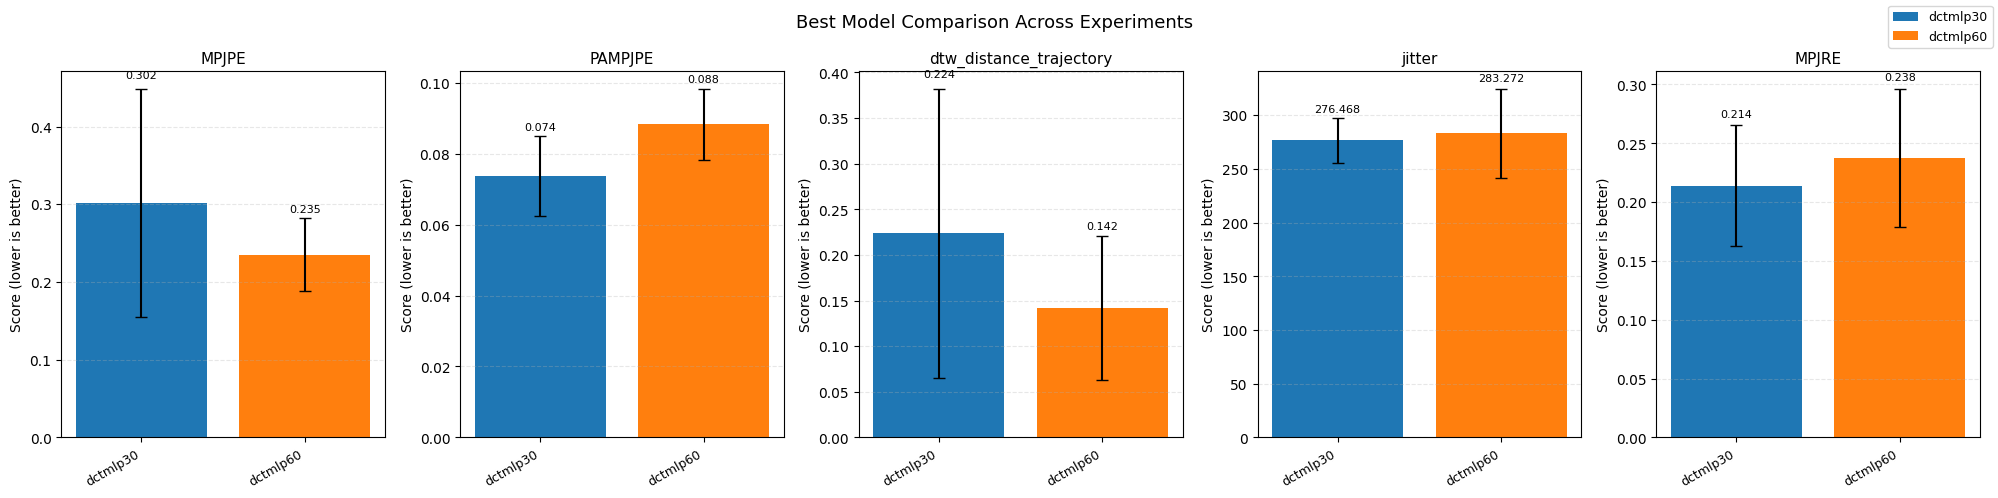

,experiment,metric,score,std,config,model
0,dctmlp30,MPJPE,0.301770,0.146813,config_dctmlp,model000049035
1,dctmlp30,PAMPJPE,0.073621,0.011212,config_dctmlp,best_model
2,dctmlp30,dtw_distance_trajectory,0.223708,0.158442,config_dctmlp,model000049035
3,dctmlp30,jitter,276.468311,20.933147,config_dctmlp,model000161035
4,dctmlp30,MPJRE,0.214052,0.051469,config_dctmlp7,model000161035
5,dctmlp30,MPJRE,0.214052,0.051469,config_dctmlp7,model000161035
6,dctmlp60,MPJPE,0.235271,0.046802,config_dctmlp6,best_model
7,dctmlp60,PAMPJPE,0.088224,0.010060,config_dctmlp4,model000035035
8,dctmlp60,dtw_distance_trajectory,0.141521,0.078983,config_dctmlp6,model000035035
9,dctmlp60,jitter,283.271608,41.311989,config_dctmlp4,model000035035


In [19]:
compare_best_models(comparison, labels, metric_keys=metric_keys)


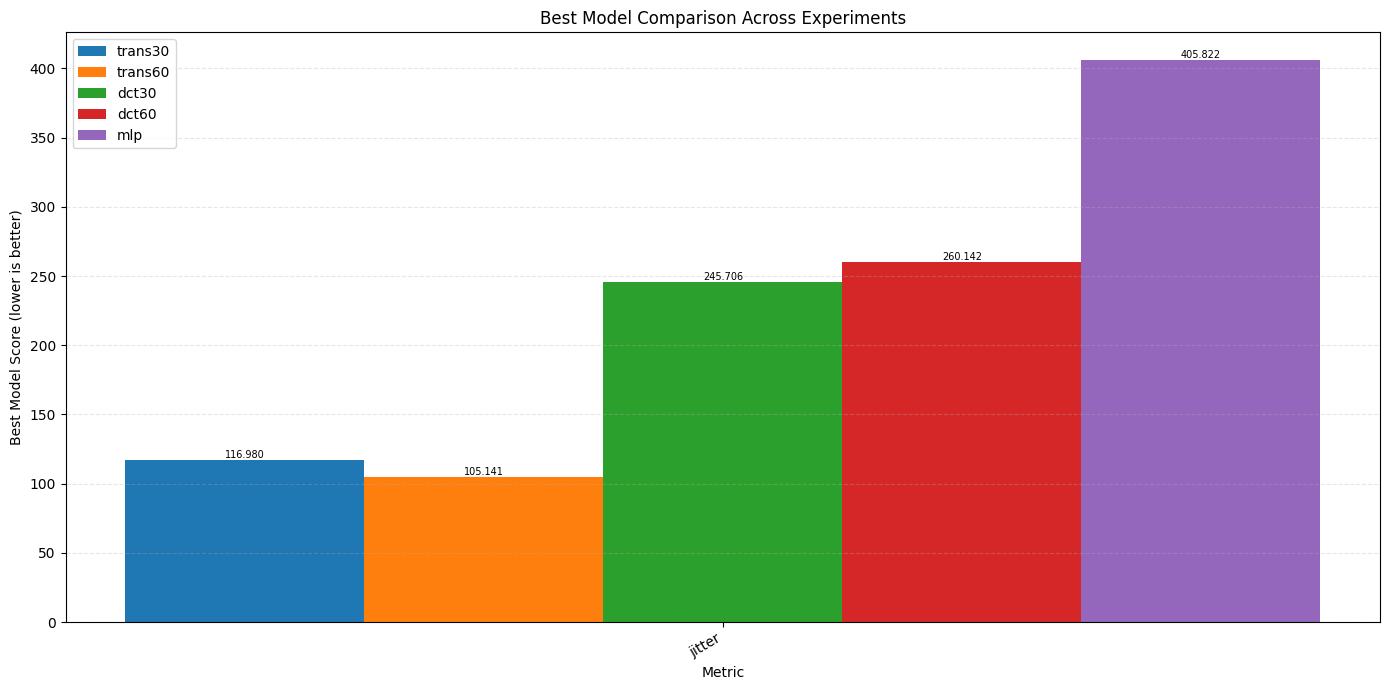

,experiment,metric,score,config,model
0,trans30,jitter,116.980273,config_transformer2_v2,model000161035
1,trans60,jitter,105.140520,config_transformer5_v2,best_model
2,dct30,jitter,245.705656,config_dcttransformer2,best_model
3,dct60,jitter,260.141707,config_dcttransformer4,model000161035
4,mlp,jitter,405.822259,config_window1_v2,model000160002


In [10]:
compare_best_models(comparison, labels, metric_keys=['jitter_mean'])

In [1]:
import numpy as np
import torch

def find_best_matching_window(seq1, seq2, start_frame1, window_size):
    """
    Finds the starting frame in seq2 that minimizes the MSE with the window 
    defined by start_frame1 and window_size in seq1.

    Args:
        seq1 (np.ndarray): The first sequence (reference). Condition
        seq2 (np.ndarray): The second sequence (search). Ground truth
        start_frame1 (int): The starting frame index in seq1.
        window_size (int): The size of the window to compare.

    Returns:
        tuple: (best_start_frame2, min_mse)
            best_start_frame2 (int): The starting index in seq2 that gives the lowest MSE.
            min_mse (float): The calculated Mean Squared Error.
    """
    # Extract the target window from seq1
    target_window = seq1[start_frame1 : start_frame1 + window_size]
    
    # Check if the window is valid within seq1
    if target_window.shape[0] != window_size:
        print("seq1 shape:", seq1.shape)
        print("seq2 shape:", seq2.shape)
        raise ValueError(f"Window size {window_size} exceeds bounds of seq1 starting at {start_frame1}")

    best_mse = 5000000.0
    best_start_frame2 = -1
    
    # Number of valid starting positions in seq2
    num_valid_starts = seq2.shape[0] - window_size + 1
    
    if num_valid_starts <= 0:
        return 0, best_mse

    # Iterate through all possible windows in seq2
    for i in range(num_valid_starts):
        candidate_window = seq2[i : i + window_size]
        
        # Calculate Mean Squared Error
        mse=torch.mean((target_window - candidate_window) ** 2) 
        
        if mse < best_mse:
            best_mse = mse
            best_start_frame2 = i
            
    return best_start_frame2, best_mse


In [ ]:
from data_loaders.dataloader3d import load_data, MotionDataset
WINDOW_SIZE = 30

a,b = load_data("mydataset", split='train', keypointtype='6d')
dataset = MotionDataset(
    "gait",
    a,
    b,
    input_motion_length=240,
)
data_pairs = dataset.data_pairs


In [17]:
match_dict={}
for action, idx_clean, idx_no_orth in data_pairs:
    orth_motion=dataset.motion_clean[action][idx_clean][:,3:]
    no_orth_motion=dataset.motion_without_orth[action][idx_no_orth][:,3:]
    orth_seq_len = orth_motion.shape[0]
    no_orth_seq_len = no_orth_motion.shape[0]
    #c2 match with c1
    key=action+str(idx_no_orth)+str(idx_clean)
    print("Processing:",key)
    list_best_frames=[]
    #case when orth_seq_len > WINDOW_SIZE and no_orth_seq_len > WINDOW_SIZE
    if no_orth_seq_len > WINDOW_SIZE:
        for start_frame in range(0, no_orth_seq_len-WINDOW_SIZE+1):
            best_start, min_mse = find_best_matching_window(
                no_orth_motion,
                orth_motion,
                start_frame,
                WINDOW_SIZE
            )
            #print(f"Action: {action}, Start Frame Orth: {start_frame}, Best Start Frame No Orth: {best_start}, Min MSE: {min_mse}")
            list_best_frames.append((start_frame, best_start))
    else:
        best_start, min_mse = find_best_matching_window(
            no_orth_motion,
            orth_motion,
            0,
            no_orth_seq_len
        )
        list_best_frames.append((0, best_start))
    match_dict[key]=list_best_frames
        

Processing: gait_011_a100
Processing: gait_011_a110
Processing: gait_011_a101
Processing: gait_011_a111
Processing: gait_011_a200
Processing: gait_011_a210
Processing: gait_011_a201
Processing: gait_011_a211
Processing: gait_011_a300
Processing: gait_011_a310
Processing: gait_011_a320
Processing: gait_011_a301
Processing: gait_011_a311
Processing: gait_011_a321
Processing: gait_011_a302
Processing: gait_011_a312
Processing: gait_011_a322
Processing: gait_011_a400
Processing: gait_011_a410
Processing: gait_011_a401
Processing: gait_011_a411
Processing: gait_011_a500
Processing: gait_011_a510
Processing: gait_011_a501
Processing: gait_011_a511
Processing: gait_052_a100
Processing: gait_052_a110
Processing: gait_052_a120
Processing: gait_052_a101
Processing: gait_052_a111
Processing: gait_052_a121
Processing: gait_052_a102
Processing: gait_052_a112
Processing: gait_052_a122
Processing: gait_052_a200
Processing: gait_052_a210
Processing: gait_052_a201
Processing: gait_052_a211
Processing: 

In [19]:
np.save("prepare_data/match_dict_window60.npy", match_dict)

In [18]:
match_dict

{'gait_011_a100': [(0, 0),
  (1, 0),
  (2, 1),
  (3, 2),
  (4, 3),
  (5, 3),
  (6, 3),
  (7, 3),
  (8, 3),
  (9, 3),
  (10, 3),
  (11, 3),
  (12, 3)],
 'gait_011_a110': [(0, 2),
  (1, 3),
  (2, 3),
  (3, 3),
  (4, 3),
  (5, 3),
  (6, 3),
  (7, 3),
  (8, 3),
  (9, 3),
  (10, 3),
  (11, 3),
  (12, 3),
  (13, 3),
  (14, 3),
  (15, 3),
  (16, 3),
  (17, 3)],
 'gait_011_a101': [(0, 7),
  (1, 7),
  (2, 0),
  (3, 0),
  (4, 0),
  (5, 0),
  (6, 0),
  (7, 0),
  (8, 0),
  (9, 0),
  (10, 0),
  (11, 0),
  (12, 0)],
 'gait_011_a111': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (5, 0),
  (6, 0),
  (7, 0),
  (8, 0),
  (9, 0),
  (10, 0),
  (11, 0),
  (12, 0),
  (13, 0),
  (14, 0),
  (15, 1),
  (16, 2),
  (17, 3)],
 'gait_011_a200': [(0, 0)],
 'gait_011_a210': [(0, 0)],
 'gait_011_a201': [(0, 0)],
 'gait_011_a211': [(0, 0)],
 'gait_011_a300': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (5, 0),
  (6, 1),
  (7, 2),
  (8, 4),
  (9, 5),
  (10, 6),
  (11, 7),
  (12, 8),
  (13, 9),
  (14, 10),
 